# Random Initialization Experiment

Runs only the non-baseline random-initialization experiment. The spectral-initialization baseline is in the dense random notebook.


device: cuda
image shape: (1, 1, 32, 32) phase img size: (1, 32, 32) signal shape: (1, 1, 32, 32) n: 1024
run: method=GD, model=deepinv_random, loss=intensity, init=random, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=Accelerated GD, model=deepinv_random, loss=intensity, init=random, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=Adam, model=deepinv_random, loss=intensity, init=random, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=NCG, model=deepinv_random, loss=intensity, init=random, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=L-BFGS, model=deepinv_random, loss=intensity, init=random, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)


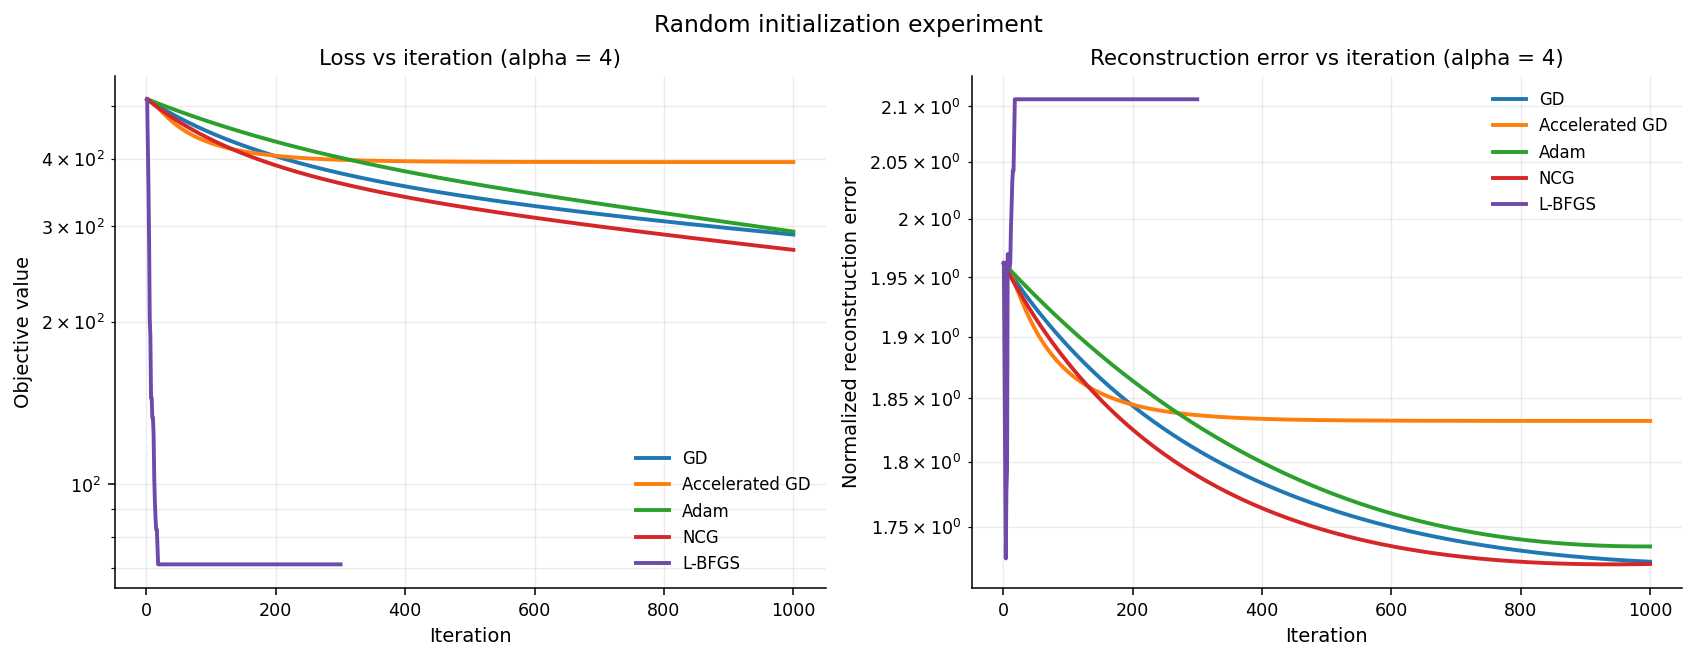

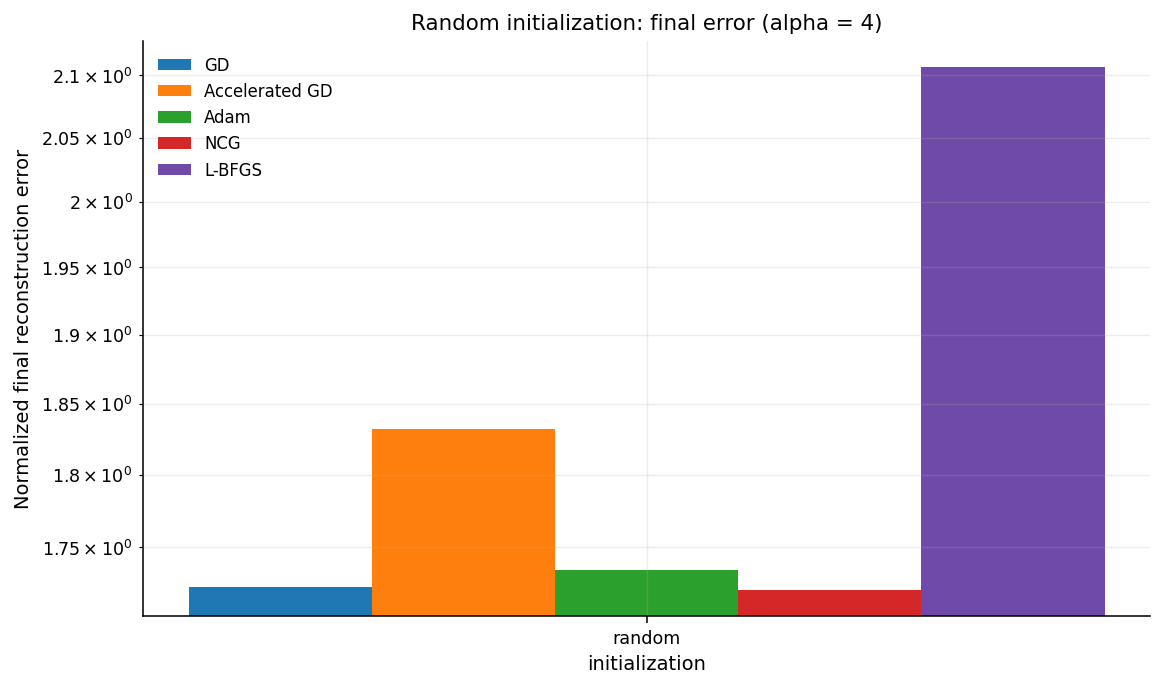

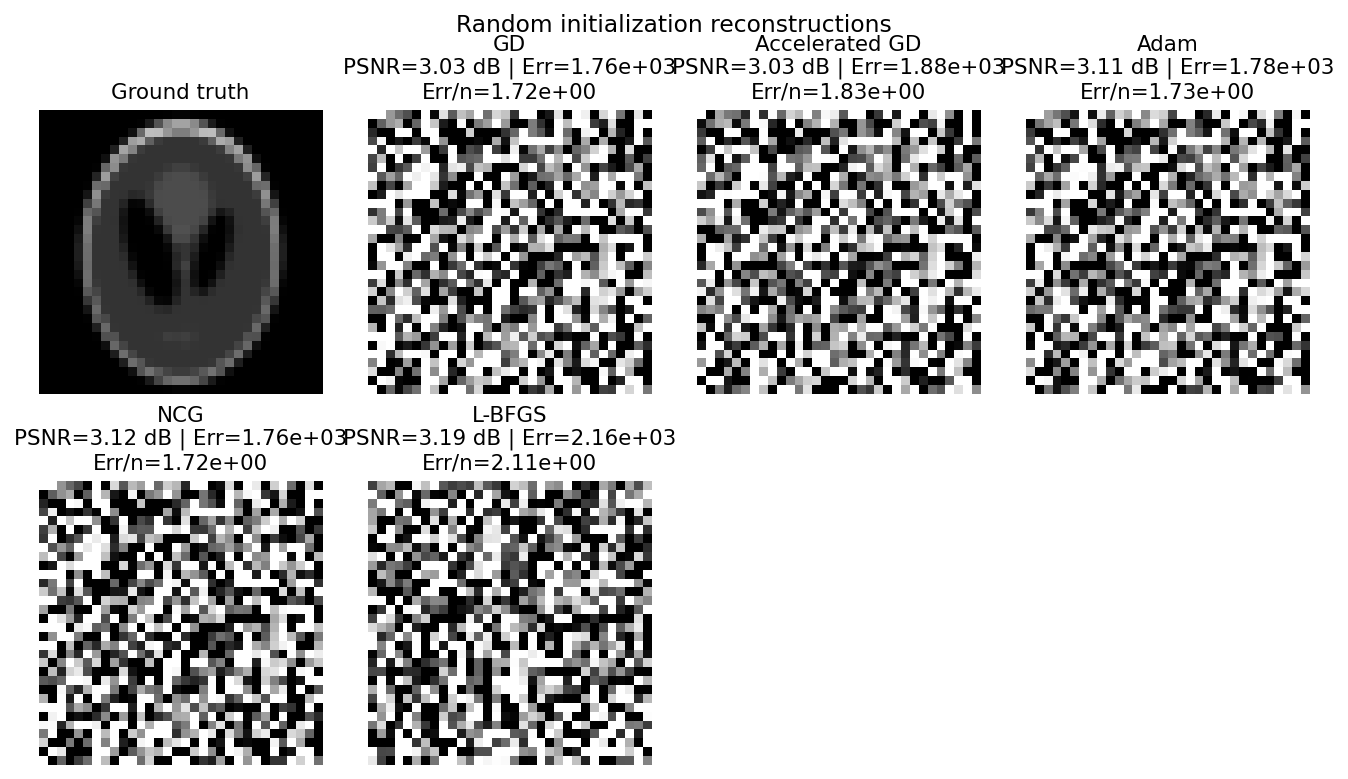

,label,method,psnr_db,final_reconstruction_error,normalized_final_reconstruction_error
0,GD,GD,3.025863,1764.863770,1.723500
1,Accelerated GD,Accelerated GD,3.028175,1876.044312,1.832075
2,Adam,Adam,3.107364,1776.597656,1.734959
3,NCG,NCG,3.122607,1763.155762,1.721832
4,L-BFGS,L-BFGS,3.187717,2157.030273,2.106475


,method,model,loss,initialization,alpha,noise_level,final_loss,final_reconstruction_error,psnr_db,runtime_seconds,iterations,success
0,GD,deepinv_random,intensity,random,4.0,0.0,289.739410,1764.863770,3.025863,11.431459,1000,False
1,Accelerated GD,deepinv_random,intensity,random,4.0,0.0,394.557861,1876.044312,3.028175,13.398875,1000,False
2,Adam,deepinv_random,intensity,random,4.0,0.0,293.504730,1776.597656,3.107364,12.151140,1000,False
3,NCG,deepinv_random,intensity,random,4.0,0.0,271.501831,1763.155762,3.122607,20.050218,1000,False
4,L-BFGS,deepinv_random,intensity,random,4.0,0.0,71.174942,2157.030273,3.187717,29.090490,300,False


In [5]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "report_experiments_split").exists():
        sys.path.insert(0, str(candidate))
        break

from report_experiments_split import config, problem, metrics, runners, plotting, common, experiment_configs
import importlib
importlib.reload(config)
importlib.reload(problem)
importlib.reload(metrics)
importlib.reload(runners)
importlib.reload(plotting)
importlib.reload(common)
importlib.reload(experiment_configs)
from report_experiments_split.experiments import initialization_comparison

importlib.reload(initialization_comparison)

outputs = initialization_comparison.run()
summary = outputs.get('summary')
summary
